In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv('placement1.csv')

In [3]:
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


Text(0.5, 1.0, 'distrubution of marks')

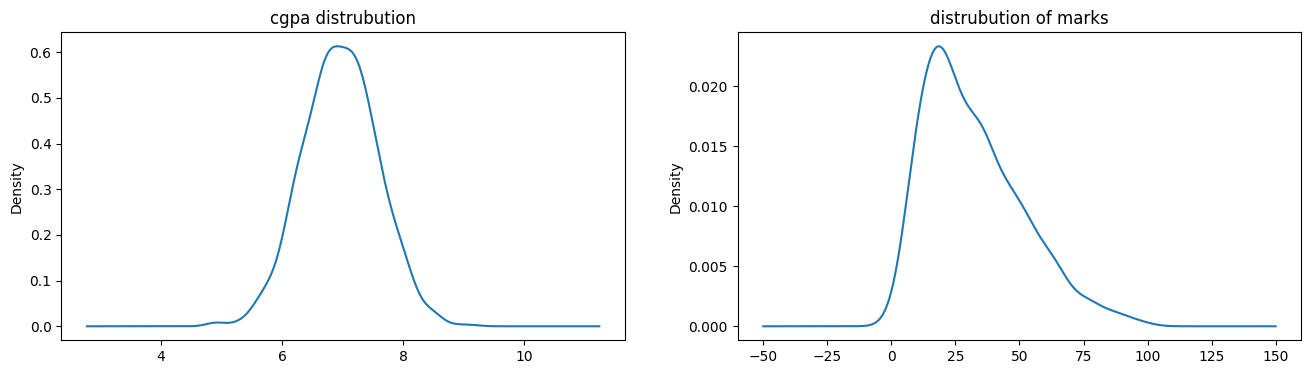

In [11]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
df['cgpa'].plot(kind='kde')
plt.title('cgpa distrubution')
plt.subplot(1,2,2)
df['placement_exam_marks'].plot(kind='kde')
plt.title('distrubution of marks')


In [12]:
mean_mark=df['placement_exam_marks'].mean()
std_mark=df['placement_exam_marks'].std()
min_mark=df['placement_exam_marks'].min()
max_marks=df['placement_exam_marks'].max()

<Axes: ylabel='placement_exam_marks'>

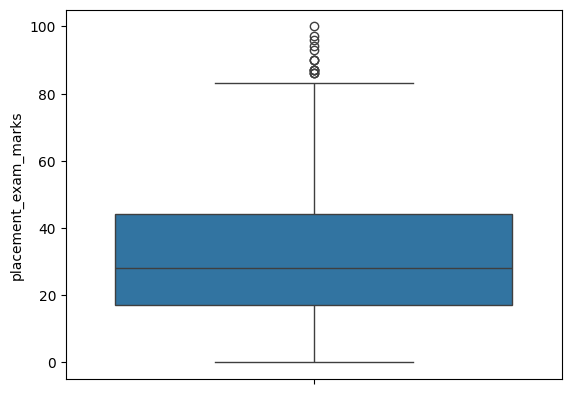

In [19]:
sns.boxplot(df['placement_exam_marks'])

In [23]:
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [24]:
IQR=percentile75-percentile25

In [31]:
print(IQR)
print(percentile75)
print(percentile25)


27.0
44.0
17.0


In [43]:
upper_limit=percentile75 + 1.5 * IQR
lower_limit=percentile25 - 1.5 * IQR

In [44]:
upper_limit

np.float64(84.5)

In [45]:
lower_limit

np.float64(-23.5)

In [46]:
df[(df['placement_exam_marks']> upper_limit)|(df['placement_exam_marks']<lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


# triming 

In [49]:
new_df=df[(df['placement_exam_marks']<upper_limit) & (df['placement_exam_marks']>lower_limit)]

In [50]:
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


Text(0.5, 1.0, 'after removing outlier')

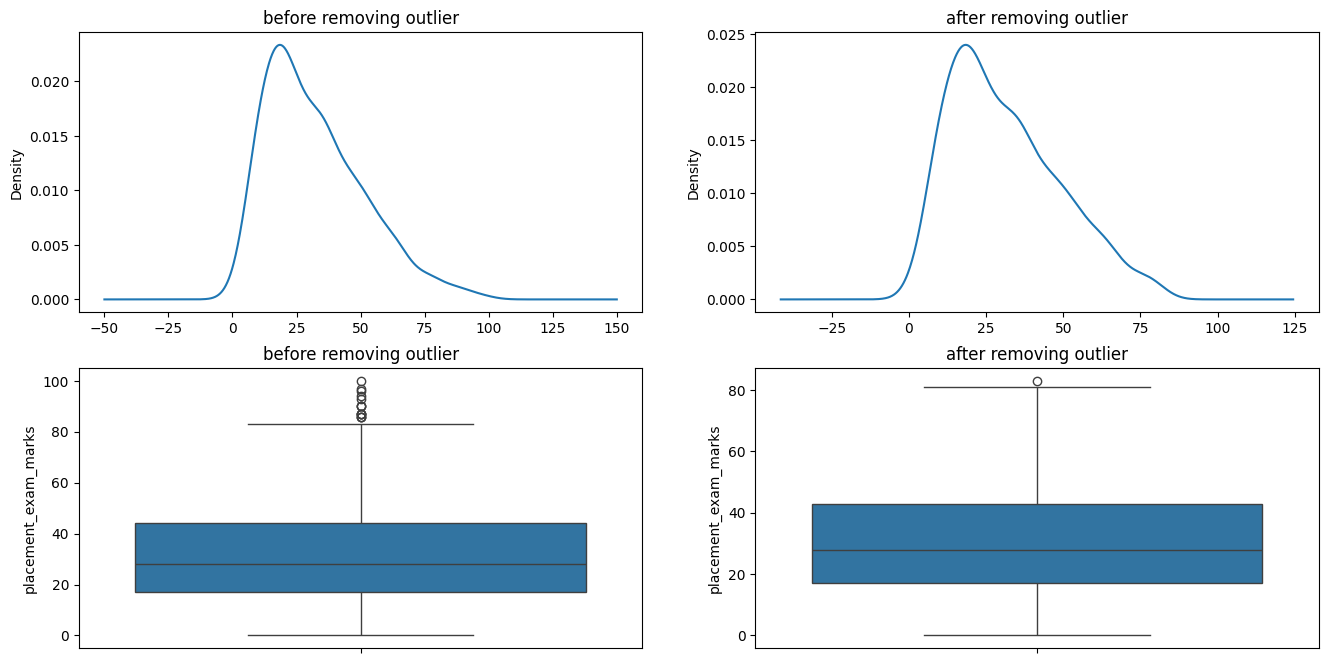

In [59]:
#comparison 
plt.figure(figsize=(16,8))
plt.subplot(221)
df['placement_exam_marks'].plot(kind='kde')
plt.title('before removing outlier')

plt.subplot(222)
new_df['placement_exam_marks'].plot(kind='kde')
plt.title('after removing outlier')

plt.subplot(223)
sns.boxplot(df['placement_exam_marks'])
plt.title('before removing outlier')

plt.subplot(224)
sns.boxplot(new_df['placement_exam_marks'])
plt.title('after removing outlier')

# capping 

In [64]:
new_df_cap=df.copy()
new_df_cap['placement_exam_marks']=np.where(
    df['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        df['placement_exam_marks']<lower_limit,
        lower_limit,
        df["placement_exam_marks"]
    )
)

In [66]:
new_df_cap

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


Text(0.5, 1.0, 'after removing outlier')

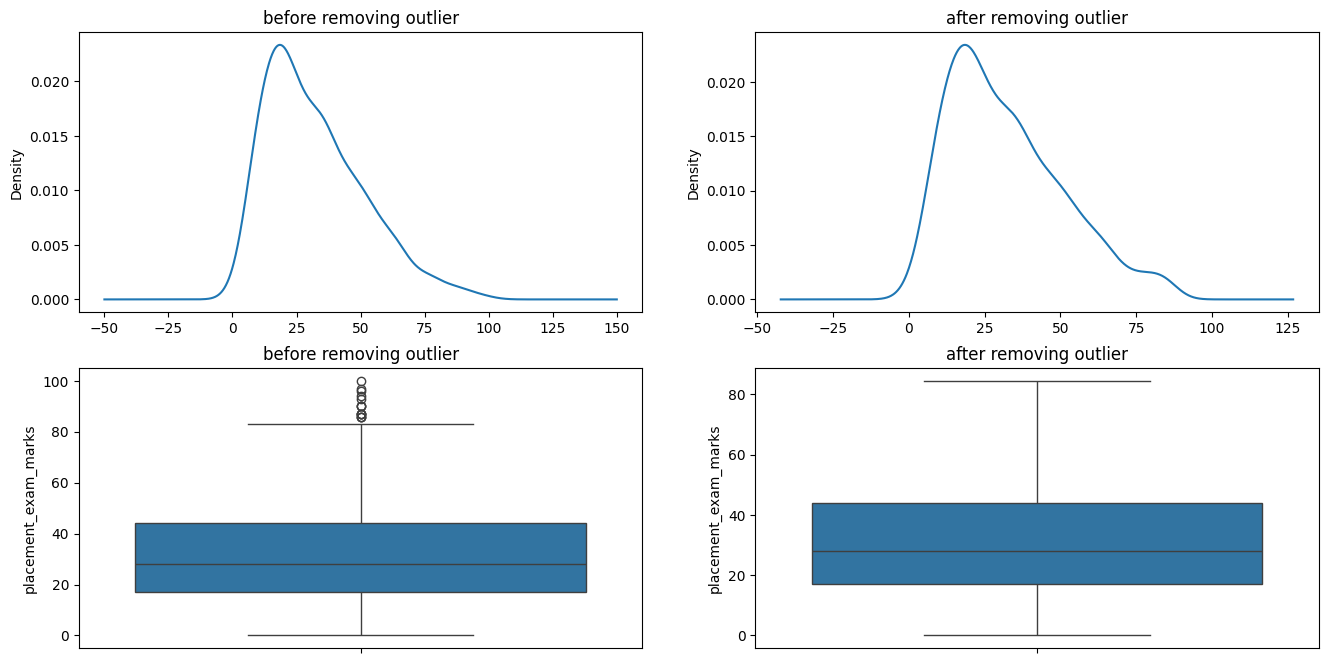

In [67]:
plt.figure(figsize=(16,8))
plt.subplot(221)
df['placement_exam_marks'].plot(kind='kde')
plt.title('before removing outlier')

plt.subplot(222)
new_df_cap['placement_exam_marks'].plot(kind='kde')
plt.title('after removing outlier')

plt.subplot(223)
sns.boxplot(df['placement_exam_marks'])
plt.title('before removing outlier')

plt.subplot(224)
sns.boxplot(new_df_cap['placement_exam_marks'])
plt.title('after removing outlier')